<a href="https://colab.research.google.com/github/irajamuller/quantum_computing/blob/main/Transformada_Qu%C3%A2ntica_de_Fourier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit --quiet
!pip install pylatexenc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [11]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, array_to_latex
import qiskit.quantum_info as qi

import numpy as np

In [40]:
def qft(qc, n):
    for i in range(n - 1, -1, -1):
        qc.h(i)
        p=0
        for j in range(i):
            p += 1
            qc.cp((np.pi / 2 ** p), i -j -1, i)
        qc.barrier()
    for i in range(int(n/2)):
        qc.swap(i,n-1-i)
    return qc

def qft_inverse(qc, n):
    qc_inverse = qft(QuantumCircuit(n), n)
    qc_inverse = qc_inverse.inverse()
    qc.append(qc_inverse, range(n))
    return qc

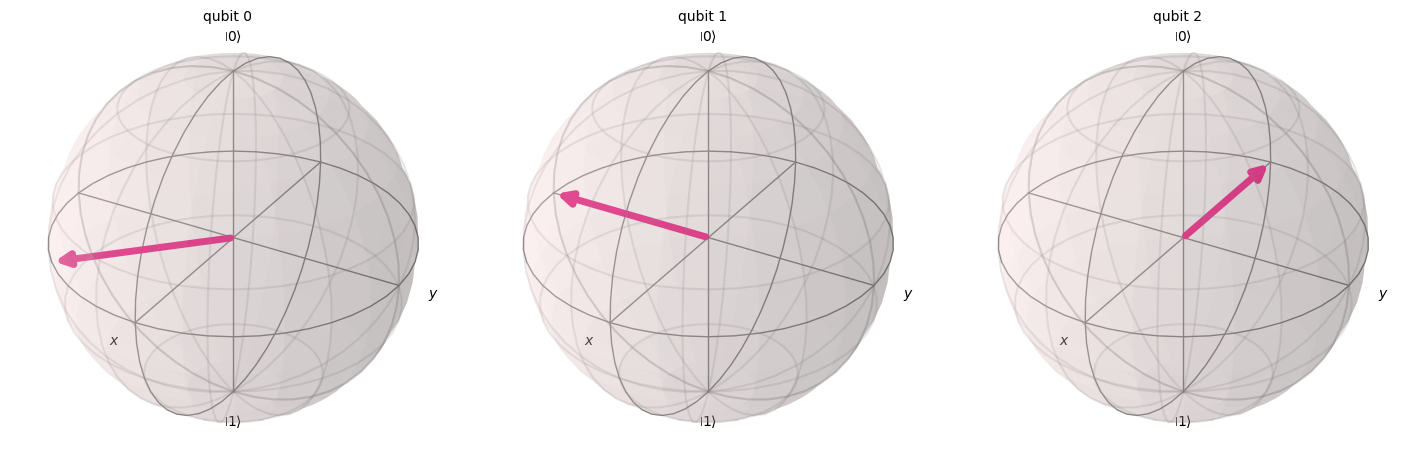

In [60]:
n = 3
qc = QuantumCircuit(n, name='QFT')
qc.initialize(qi.Statevector.from_label("111"), range(n))
#qc.initialize(qi.Statevector.from_label('0101'), range(n))
#qc.initialize([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], range(n))

qft(qc, n)

state_vector = qi.Statevector(qc)

plot_bloch_multivector(state_vector)

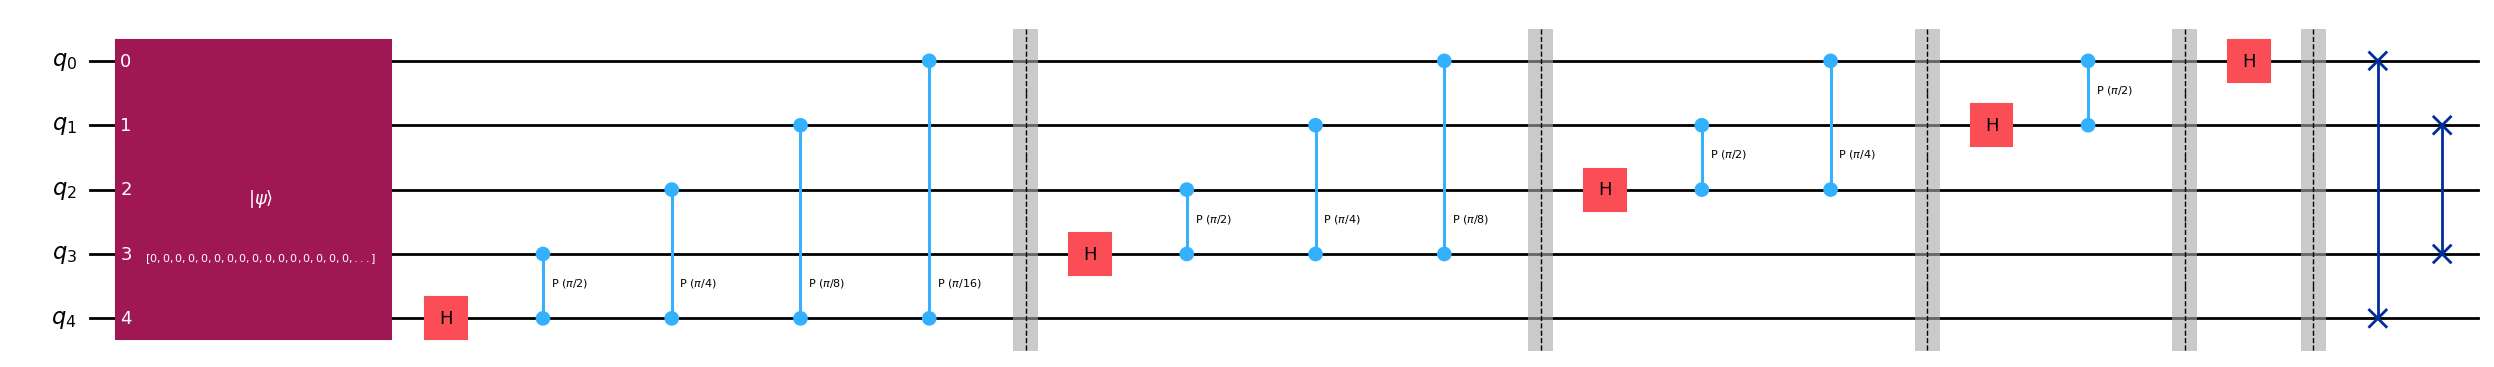

In [45]:
qc.draw(output='mpl', fold=1)

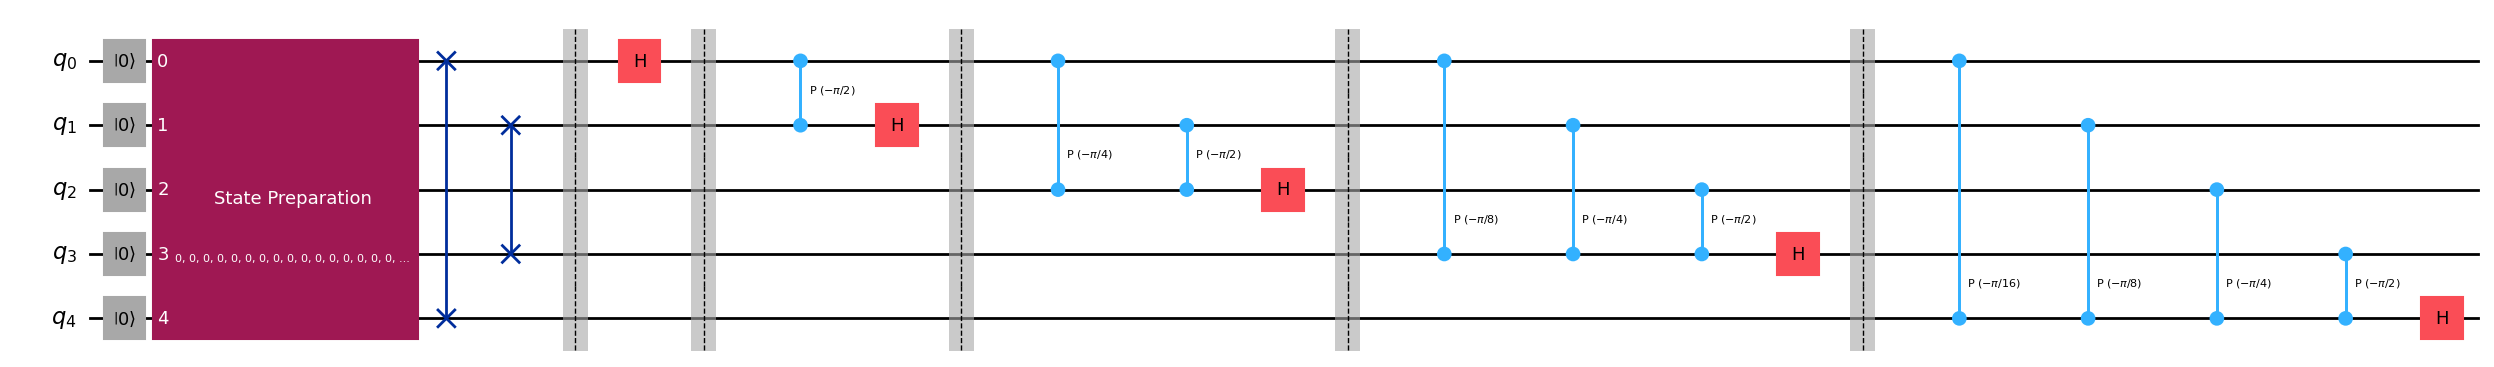

In [52]:
n = 5
qc = QuantumCircuit(n, name='QFT-inverse')
#qc.initialize(state_vector, range(n))
qc.initialize(qi.Statevector.from_label("10000"), range(n))

qft_inverse(qc, n)
qc.decompose().draw('mpl', fold=1)

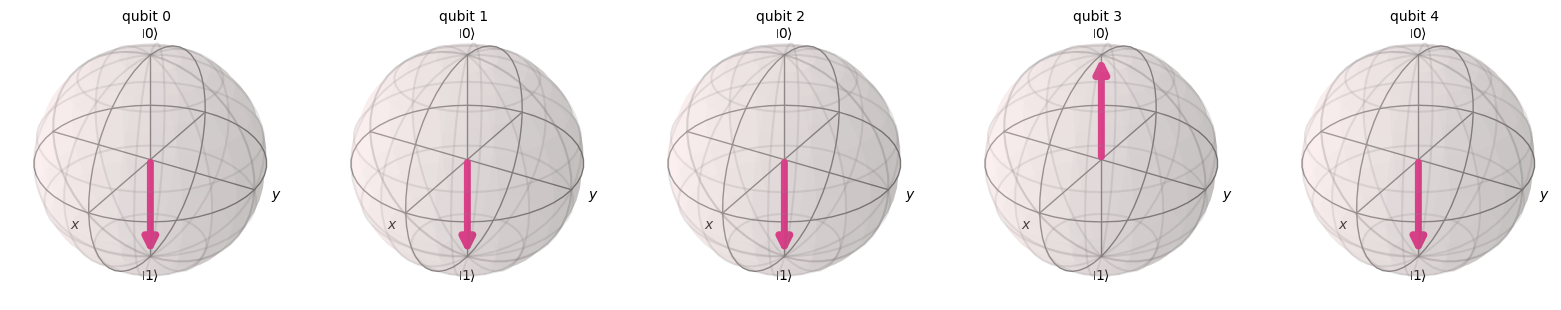

In [47]:
plot_bloch_multivector(qi.Statevector(qc))